## Carregamento dos Dados

- Nesta etapa, realizamos a leitura dos dados brutos. Para otimizar o uso de memória, já convertemos as colunas de IDs para string e as colunas categóricas para o tipo 'category'.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# importando a base de dados e modificando os tipos de dados para o ideal em cada coluna.
df  = pd.read_csv('Base Varejo.csv', sep=';', dtype= {'CO_ID':str,'CL_ID':str,'CL_GENERO':'category','CL_SEG':'category','PR_ID':str,'PR_CAT':'category'})

# criaçao da copia da nossa base de dados
df_copy = df.copy()

# alterando o formato da coluna 'DATA'
df_copy['DATA'] = pd.to_datetime(df['DATA'], dayfirst=True)

In [76]:
# recolhendo amostras
print(df_copy.head(10))

        DATA CO_ID CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG PR_ID     PR_CAT  \
0 2019-02-01  1000   534         M      4       1      C    67    BEBIDAS   
1 2019-02-01  1000   534         M      4       1      C    70    BEBIDAS   
2 2019-02-01  1000   534         M      4       1      C   178    HIGIENE   
3 2019-02-01  1000   534         M      4       1      C     4  ALIMENTOS   
4 2019-02-01  1000   534         M      4       1      C   175    LIMPEZA   
5 2019-02-01  1000   534         M      4       1      C   187    HIGIENE   
6 2019-02-01  1000   534         M      4       1      C   163  ALIMENTOS   
7 2019-02-01  1000   534         M      4       1      C    11  ALIMENTOS   
8 2019-02-01  1000   534         M      4       1      C    95    LIMPEZA   
9 2019-02-01  1000   534         M      4       1      C   198    BEBIDAS   

                PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0  REFRIGERANTE GUARANA          NaN          NaN          NaN          Na

In [77]:
# verificaçao de tipos de dados
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   DATA         830000 non-null  datetime64[us]
 1   CO_ID        830000 non-null  str           
 2   CL_ID        830000 non-null  str           
 3   CL_GENERO    830000 non-null  category      
 4   CL_EC        830000 non-null  int64         
 5   CL_FHL       830000 non-null  int64         
 6   CL_SEG       830000 non-null  category      
 7   PR_ID        830000 non-null  str           
 8   PR_CAT       830000 non-null  category      
 9   PR_NOME      830000 non-null  str           
 10  Unnamed: 10  0 non-null       float64       
 11  Unnamed: 11  0 non-null       float64       
 12  Unnamed: 12  0 non-null       float64       
 13  Unnamed: 13  0 non-null       float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 72.0 MB


## Identificando Problemas

- Antes de qualquer análise, precisamos garantir a confiabilidade da base. Vamos investigar a presença de valores nulos e possíveis registros duplicados.

In [78]:
# verificaçao com precentual de nulos:
print((df_copy.isnull().sum() / len(df_copy) * 100).round(2))

DATA             0.0
CO_ID            0.0
CL_ID            0.0
CL_GENERO        0.0
CL_EC            0.0
CL_FHL           0.0
CL_SEG           0.0
PR_ID            0.0
PR_CAT           0.0
PR_NOME          0.0
Unnamed: 10    100.0
Unnamed: 11    100.0
Unnamed: 12    100.0
Unnamed: 13    100.0
dtype: float64


In [79]:
# verificando duplicatas
df_copy.duplicated().sum()


np.int64(96553)

## Tratamento e Limpeza dos Dados

- Ao investigar as duplicatas, notamos um padrão no espaçamento dos índices. Isso indica que não houve falha sistêmica, mas sim o registro sequencial de múltiplos produtos iguais no caixa.


- Ação: Para não perder histórico de vendas valioso, criamos uma nova coluna QTD_PR agrupando essas ocorrências.

In [80]:
# exibiçao em dataframe, para analisarmos melhor a questao das duplicatas

# filtra a base, mostrando as linhas que possuem copias iguais
duplicatas = df_copy[df_copy.duplicated(keep=False)]

# como queremos descobrir se a questao das duplicatas tem algo haver com o id do cliente e o id do produto as ordemos dessa forma para  que facilite nossa analise
duplicatas.sort_values(by=['CO_ID', 'PR_ID']).head(10)


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
7,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN
46,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN
14,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN
19,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN
15,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE,NaN,NaN,NaN,NaN
50,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE,NaN,NaN,NaN,NaN
34,2019-02-01,1000,534,M,4,1,C,225,ALIMENTOS,ATUM,NaN,NaN,NaN,NaN
51,2019-02-01,1000,534,M,4,1,C,225,ALIMENTOS,ATUM,NaN,NaN,NaN,NaN
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
40,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN


In [81]:
# apos a analise anterior, decidimos criar uma nova coluna de quantidade, contendo as linhas duplicadas
coluna = df_copy.columns.tolist()
df_copy = df_copy.groupby(coluna, dropna=False).size().reset_index(name='QTD_PR')

df_copy[df_copy['CO_ID'] == '1000'].head(10)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,QTD_PR
6492,2019-02-01,1000,534,M,4,1,C,108,LIMPEZA,REMOVEDOR,NaN,NaN,NaN,NaN,1
6493,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN,2
6494,2019-02-01,1000,534,M,4,1,C,121,ALIMENTOS,UVA,NaN,NaN,NaN,NaN,1
6495,2019-02-01,1000,534,M,4,1,C,123,LIMPEZA,TIRA MANCHA,NaN,NaN,NaN,NaN,1
6496,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN,2
6497,2019-02-01,1000,534,M,4,1,C,132,HIGIENE,SABONETE,NaN,NaN,NaN,NaN,1
6498,2019-02-01,1000,534,M,4,1,C,135,LIMPEZA,RODO,NaN,NaN,NaN,NaN,1
6499,2019-02-01,1000,534,M,4,1,C,136,ALIMENTOS,RICOTA,NaN,NaN,NaN,NaN,1
6500,2019-02-01,1000,534,M,4,1,C,143,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN,1
6501,2019-02-01,1000,534,M,4,1,C,149,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN,1


In [82]:
# removendo colunas inteiramente vazias, pois nao fara sentido ter elas dentro da nossa base de dados que posteriormente sera utilizada por alguem
df_copy = df_copy.drop(columns= ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

In [83]:
# correcao de inconssisetncias nas colunas PR_CAT e PR_NOME
df_copy['PR_CAT'] = df_copy['PR_CAT'].str.capitalize()
df_copy['PR_NOME'] = df_copy['PR_NOME'].str.capitalize()

In [84]:
# modificando o estado civil para estar condizente com a documentaçao e as regras de negocio da empresa:
map_df = {1:'Casado/Uniao Estavel', 2:'Divorciado', 3:'Separado', 4:'Solteiro', 5:'Viuvo'}
df_copy['CL_EC'] = df_copy['CL_EC'].map(map_df)

In [85]:
# vendo quantas linhas temos valores nulos/ausentes ou #N/D
df_copy[df_copy['PR_CAT'] == '#n/d'].shape[0]

3228

In [86]:
# vamos substituir a string '#N/D' por valores nulos, pois na etapa de verificaçao nao foi constatado
df_copy['PR_CAT'] = df_copy['PR_CAT'].replace('#n/d', np.nan)
df_copy['PR_NOME'] = df_copy['PR_NOME'].replace('#n/d', np.nan)

# removendo nulos
df_copy = df_copy.dropna(subset=['PR_CAT', 'PR_NOME'])

# transformando novamente o PR_CAT em categoria
df_copy['PR_CAT'] = df_copy['PR_CAT'].astype('category')



- Removemos os valores nulos apos analisar as colunas PR_CAT, PR_NOME e PR_ID pois com os dados atuais se torna impossivel de recuperar  <br> esses 3.228 valores nulos/ausentes, iremos remover eles pois como sao poucos e nao tem maneira alguma de os recuperar, nao farao falta na nossa base



## Estatísticas Descritivas

In [87]:
# filtraremos apenas colunas de texto (object), categorias (category) e texto (strings)
df_copy.describe(include=['object', 'category', 'str'])

,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_SEG,PR_ID,PR_CAT,PR_NOME
count,730219,730219,730219,730219,730219,730219,730219,730219
unique,18469,1000,2,5,3,228,6,117
top,173489,822,F,Separado,B,51,Alimentos,Presunto cozido
freq,81,1527,380735,188238,466441,3322,384197,12719


In [88]:
# obtendo as principais estatisticas descritivas dos dados
def descritivas(data):
  variaveis = data.select_dtypes(include=np.number)
  desc = variaveis.describe().T
  desc["CV"] = desc["std"]/desc["mean"]
  desc["Skew"] = variaveis.skew()
  desc["Kurtosis"] = variaveis.kurt()
  ordered_cols = [
      "count", "mean", "std", "CV",
      "min", "25%", "50%", "75%", "max",
      "Skew", "Kurtosis"
  ]
  desc = desc[ordered_cols]
  return desc.round(2)


In [89]:
# analise descritiva da coluna CL_FHL (quantidade de filhos por cliente)
descritivas(df_copy[['CL_FHL']])

,count,mean,std,CV,min,25%,50%,75%,max,Skew,Kurtosis
CL_FHL,730219.0,1.15,1.42,1.24,0.0,0.0,0.0,2.0,4.0,0.82,-0.79


## Analise Exploratorio e Agrupamentos

#### Quem compra mais?

In [90]:
# quem compra mais da categoria de generos

#agrupando os dados pelo gênero e somando o volume de produtos
volume_por_genero = df_copy.groupby('CL_GENERO')['QTD_PR'].sum().reset_index()
volume_por_genero = volume_por_genero.rename(columns={'QTD_PR': 'Volume_Total'})

volume_por_genero = volume_por_genero.sort_values(by='Volume_Total', ascending=False)

volume_por_genero

,CL_GENERO,Volume_Total
0,F,430658
1,M,395692


C:\Users\Mirtu\AppData\Local\Temp\ipykernel_4404\4166478679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volume_por_genero, x='CL_GENERO', y='Volume_Total', palette='viridis')


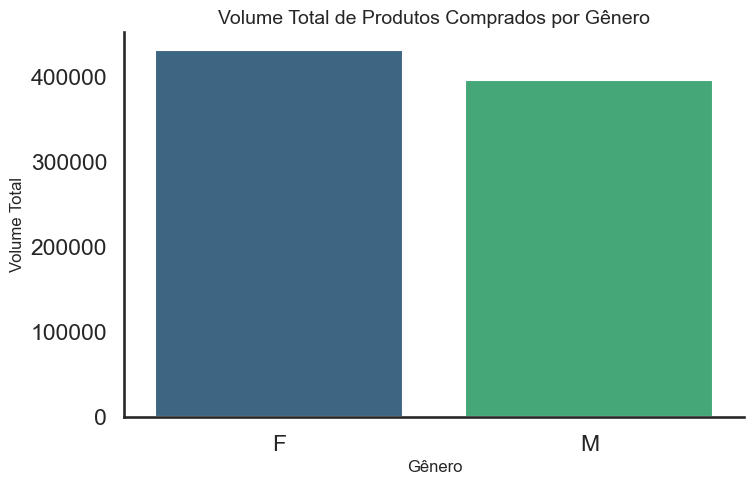

In [91]:
# grafico do volume por genero
plt.figure(figsize=(8, 5)) 

sns.barplot(data=volume_por_genero, x='CL_GENERO', y='Volume_Total', palette='viridis')
plt.title('Volume Total de Produtos Comprados por Gênero', fontsize=14)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Volume Total', fontsize=12)
sns.despine() 

plt.show()

In [92]:
# fazendo um Drill-Down para olharmos mais fundo
drill_down_genero_cat = df_copy.pivot_table(
    index='PR_CAT',       
    columns='CL_GENERO',  
    values='QTD_PR',      
    aggfunc='sum'         
)

drill_down_genero_cat

CL_GENERO,F,M
PR_CAT,,
Acessorios,7700,6857
Alimentos,226575,208192
Bebidas,22345,20954
Higiene,80991,74583
Limpeza,76298,69456
Pet,16749,15650


In [93]:
# quem compra mais em volume de produtos?
volume_cliente = df_copy.groupby('CL_ID')['QTD_PR'].sum().reset_index()
volume_cliente = volume_cliente.rename(columns={'QTD_PR': 'Qtd_Produtos'})

top_clientes_volume = volume_cliente.sort_values(by='Qtd_Produtos', ascending=False).head(10)

top_clientes_volume

,CL_ID,Qtd_Produtos
804,822,1772
429,485,1644
300,369,1524
331,397,1501
969,971,1493
27,122,1459
14,110,1426
360,422,1421
808,826,1410
223,3,1398


In [94]:
# verificaçao de clientes padrao ouro

volume_cliente['Qtd_Produtos'].describe()
percentis = volume_cliente['Qtd_Produtos'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

percentis

0.10     550.90
0.25     657.00
0.50     818.50
0.75     977.25
0.90    1112.00
0.95    1238.05
0.99    1396.02
Name: Qtd_Produtos, dtype: float64

#### Quais categorias vendem mais (em volume total)?

In [95]:
# abaixo criamos um agrupamento para sabermos quais categorias mais vendem
vendas_categoria = df_copy.groupby('PR_CAT')['QTD_PR'].sum().reset_index()
vendas_categoria = vendas_categoria.rename(columns={'QTD_PR': 'Volume_Total_Vendido'})

# ordenando as categorias
vendas_categoria = vendas_categoria.sort_values(by='Volume_Total_Vendido', ascending=False)

vendas_categoria

,PR_CAT,Volume_Total_Vendido
1,Alimentos,434767
3,Higiene,155574
4,Limpeza,145754
2,Bebidas,43299
5,Pet,32399
0,Acessorios,14557


C:\Users\Mirtu\AppData\Local\Temp\ipykernel_4404\637370482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_categoria, x='Volume_Total_Vendido', y='PR_CAT', palette='coolwarm')


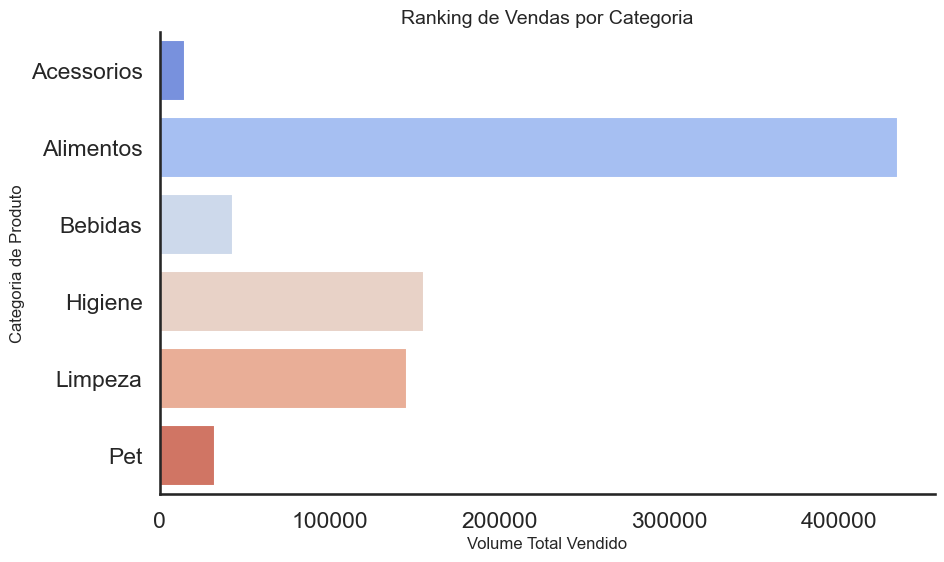

In [96]:
# grafico do ranking das vendas
plt.figure(figsize=(10, 6))

sns.barplot(data=vendas_categoria, x='Volume_Total_Vendido', y='PR_CAT', palette='coolwarm')

plt.title('Ranking de Vendas por Categoria', fontsize=14)
plt.xlabel('Volume Total Vendido', fontsize=12)
plt.ylabel('Categoria de Produto', fontsize=12)
sns.despine()

plt.show()

In [97]:
# abaixo estamos pegando a categoria vencedora do codigo anterior 
categoria_campea = vendas_categoria.iloc[0]['PR_CAT']
print(f"Analisando a Categoria Campeã: {categoria_campea}\n")

# filtra o dataframe so para essa categoria e agrupa por Produto
df_campea = df_copy[df_copy['PR_CAT'] == categoria_campea]

# criando agrupamento para vermos por dentro da categoria, quais produtos mais vendem
produtos_da_categoria = df_campea.groupby('PR_NOME')['QTD_PR'].sum().reset_index() 
produtos_da_categoria = produtos_da_categoria.rename(columns={'QTD_PR': 'Volume'})
produtos_da_categoria = produtos_da_categoria.sort_values(by='Volume', ascending=False).head(10)

produtos_da_categoria

Analisando a Categoria Campeã: Alimentos



,PR_NOME,Volume
50,Presunto cozido,14381
57,Sardinha,7490
10,Banana,7385
13,Bife de coxao mole,7355
48,Papinha infantil,7346
56,Salgadinhos de milho,7345
22,Coracao de frango,7342
54,Ricota,7334
17,Cebola,7321
11,Batata,7309


C:\Users\Mirtu\AppData\Local\Temp\ipykernel_4404\2738536816.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=produtos_da_categoria, x='Volume', y='PR_NOME', palette='coolwarm')


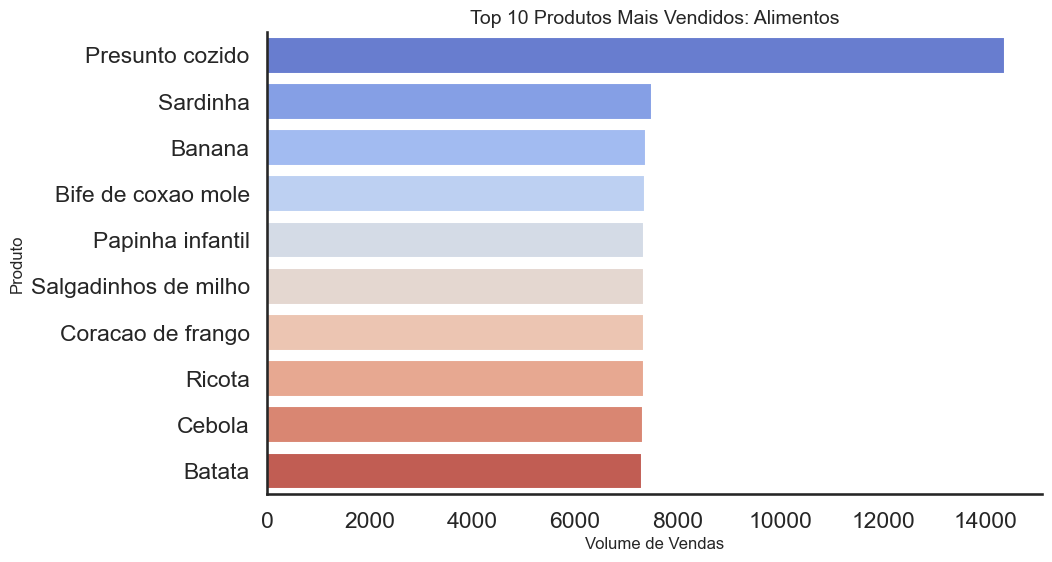

In [98]:

# grafico dos produtos mais vendidos
plt.figure(figsize=(10, 6))

sns.barplot(data=produtos_da_categoria, x='Volume', y='PR_NOME', palette='coolwarm')

plt.title(f'Top 10 Produtos Mais Vendidos: {categoria_campea}', fontsize=14)
plt.xlabel('Volume de Vendas', fontsize=12)
plt.ylabel('Produto', fontsize=12)
sns.despine()

plt.show()

#### Como variam as vendas ao longo do tempo?

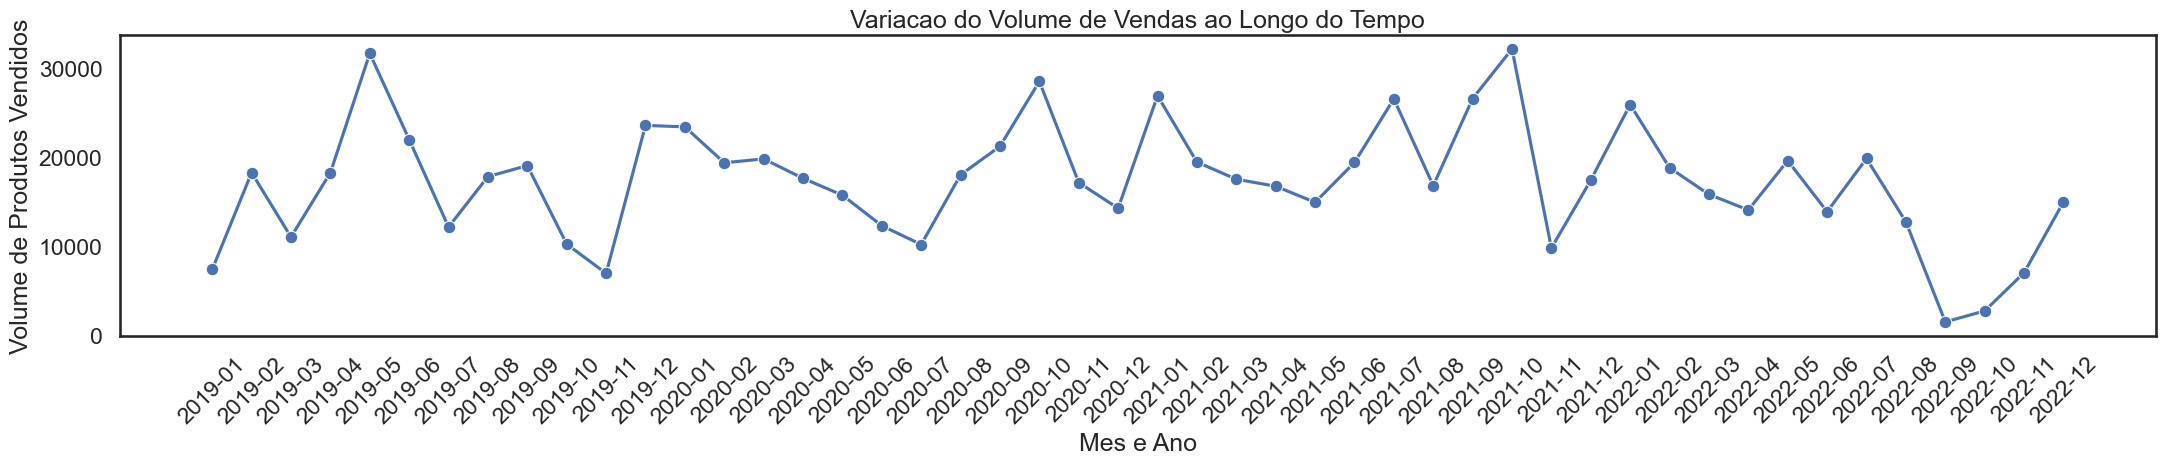

In [ ]:
# criaçao de uma coluna ano mes para nosso grafico abaixo
df_copy['Ano_Mes'] = df_copy['DATA'].dt.to_period('M')

# agrupando as vendas ao longo dos meses
vendas_tempo = df_copy.groupby('Ano_Mes')['QTD_PR'].sum().reset_index()

# conversao da coluna ano_mes para string, para facilitar a plotagem
vendas_tempo['Ano_Mes'] = vendas_tempo['Ano_Mes'].astype(str)

# abaixo iremos fazer um grafico de linha para termos noçao de como variam as vendas ao longo do tempo
plt.figure(figsize=(22, 5))
sns.lineplot(data=vendas_tempo, x='Ano_Mes', y='QTD_PR', marker='o')
plt.title('Variacao do Volume de Vendas ao Longo do Tempo')
plt.xlabel('Mes e Ano')
plt.ylabel('Volume de Produtos Vendidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
# vamos extrair o dia da semana (0 = Segunda, 6 = Domingo)
df_copy['Dia_Semana'] = df_copy['DATA'].dt.dayofweek

dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df_copy['Nome_Dia'] = df_copy['Dia_Semana'].map(dias_map)

# agrupando o volume de vendas por dia da semana
vendas_por_dia = df_copy.groupby('Nome_Dia')['QTD_PR'].sum().reindex(list(dias_map.values())).reset_index()
vendas_por_dia

,Nome_Dia,QTD_PR
0,Segunda,111288
1,Terça,101194
2,Quarta,152908
3,Quinta,105030
4,Sexta,132019
5,Sábado,93979
6,Domingo,129932


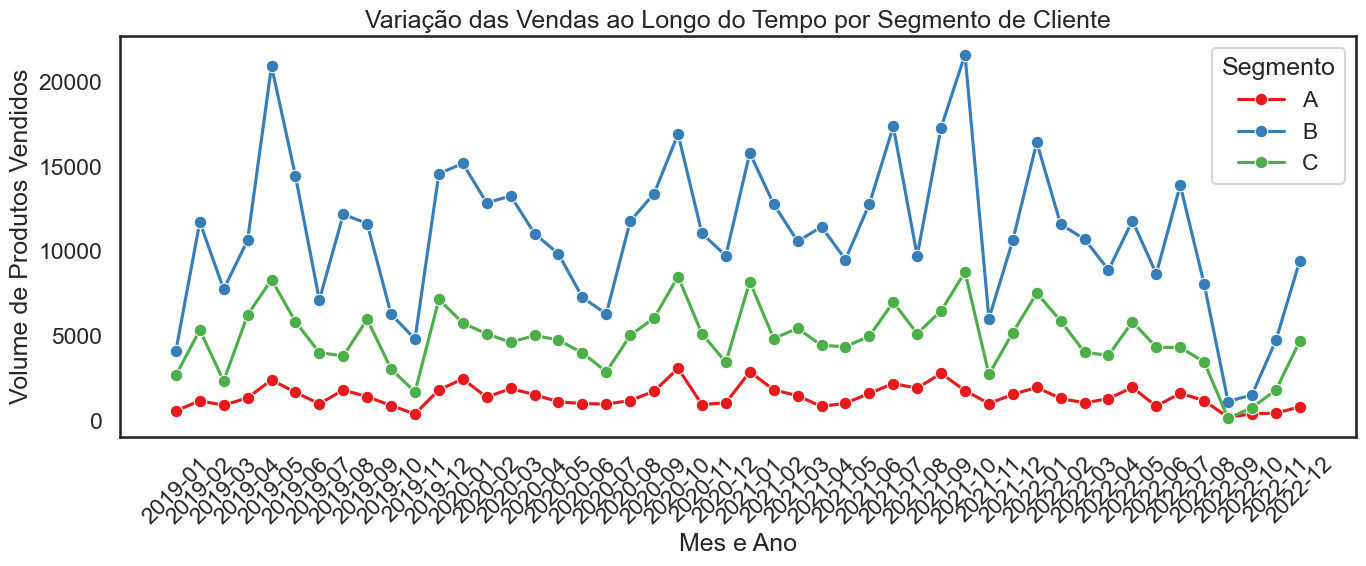

In [101]:
# modificando a coluna ano mes para string, pois so assim dara para fazero grafico para melhor visualizaçao
df_copy['Ano_Mes'] = df_copy['DATA'].dt.to_period('M').astype(str)

# agrupamos por ano_mes E por segmento (CL_SEG)
vendas_tempo_segmento = df_copy.groupby(['Ano_Mes', 'CL_SEG'])['QTD_PR'].sum().reset_index()

# criaçao do gráfico de linha por segmento
plt.figure(figsize=(14, 6))
sns.lineplot(data=vendas_tempo_segmento, x='Ano_Mes', y='QTD_PR', hue='CL_SEG', marker='o', palette='Set1')

plt.title('Variação das Vendas ao Longo do Tempo por Segmento de Cliente')
plt.xlabel('Mes e Ano')
plt.ylabel('Volume de Produtos Vendidos')
plt.xticks(rotation=45)
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()